# Icarus — frame-inspector (docentversie)

Deze notebook laat in een paar stappen zien wat de Icarus-pijplijn met **één enkel frame**
doet. Een *frame* is een schermafbeelding van het orderbord; de pijplijn knipt daar
*segmenten* (losse orders) uit, leest met OCR het **ordernummer** en het **adres**, en
zoekt dat adres later op in de adresdatabase.

Je kunt deze notebook van boven naar beneden uitvoeren (Kernel → Restart & Run All).
Er is bewust maar **één frame** bij geleverd: `001500.png`. Alle stappen werken op dat frame.

> De segmentvakken worden hier *opnieuw berekend* uit de PNG. Ze staan met opzet niet in
> `sim.json` opgeslagen — die file bevat alleen het eindresultaat van de pijplijn.


## Setup
Imports en paden. We draaien vanuit `notebooks/`, dus de projectroot ligt één map hoger.

In [5]:
import sys, json, pathlib
import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd().parent          # vanuit notebooks/ -> projectroot één map hoger
sys.path.insert(0, str(ROOT))
from icarus.resolve.segmenter import prepare, get_segments

FRAMES_DIR = ROOT / "sim" / "frames"
SIM_JSON   = ROOT / "sim" / "out" / "sim.json"

FRAME = "001500.png"                      # het enige meegeleverde frame
print("frame  :", FRAMES_DIR / FRAME)
print("bestaat:", (FRAMES_DIR / FRAME).exists())


frame  : /app/sim/frames/001500.png
bestaat: True


## Stap 1 — frame inladen en segmenteren

`prepare()` zet de ruwe PNG om in een intern frame-object; `get_segments()` vindt daarin de
losse orders. We printen hoeveel segmenten gevonden zijn en welke als *timed* gemarkeerd zijn
(een timed-segment is een order zonder uitleesbaar adres, bv. een tijdslot).

In [6]:
img = cv2.imread(str(FRAMES_DIR / FRAME))
assert img is not None, f"{FRAME} niet gevonden in {FRAMES_DIR}"

fr   = prepare(img)
segs = get_segments(fr)

print(f"{len(segs)} segmenten gevonden")
print("timed per segment:", [s.timed for s in segs])


10 segmenten gevonden
timed per segment: [False, False, False, False, False, False, False, False, False, False]


## Stap 2 — de segmentvakken tekenen

`draw()` tekent de gevonden kaders over het frame heen. De kleuren (zoals ze hieronder
verschijnen):

- **cyaan** — een *timed* segment
- **oranje** — een gewoon segment
- **groen** — het ordernummer-vakje
- **rood** — de losse tekstregels (waar het adres staat)

Zo zie je in één oogopslag of de segmentatie netjes om elke order heen valt.

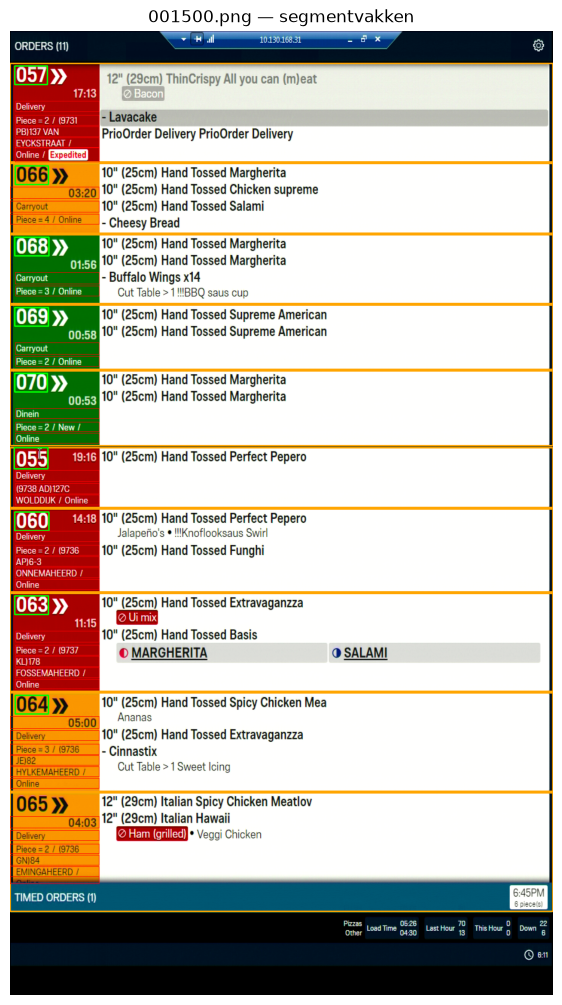

In [7]:
def draw(frame):
    ann = frame.bgr.copy()
    for s in frame.segments:
        r = s.region
        cv2.rectangle(ann, (r.x0, r.y0), (r.x1, r.y1),
                      (255, 255, 0) if s.timed else (0, 165, 255), 2)
        if s.number:
            n = s.number
            cv2.rectangle(ann, (n.x0, n.y0), (n.x1, n.y1), (0, 255, 0), 2)
        for rw in s.rows:
            cv2.rectangle(ann, (rw.x0, rw.y0), (rw.x1, rw.y1), (0, 0, 255), 1)
    return ann

plt.figure(figsize=(7, 14))
plt.imshow(cv2.cvtColor(draw(fr), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"{FRAME} — segmentvakken")
plt.show()


## Stap 3 — wat de OCR per segment leest

Voor elk segment lezen we het **ordernummer** en het **adres** uit. Het adres gaat — net als in
de echte pijplijn — in **twee passes** over de adres-strook:

- **letters-pass** (`addr_read`) → straat + postcode
- **cijfer-pass** (`addr_digits_read`) → huisnummer

De twee passes gebruiken bewust een andere voorbewerking (`g8` = grijswaarden + 8× voor de
letters, `g4` = 4× voor de cijfers). Een harde drempel zou anders de `(` aan het eerste
postcodecijfer plakken en dat cijfer opeten. Timed of lege segmenten leveren geen adres-strook
op en blijven leeg. Elke uitlezing staat in een `try/except`, zodat de notebook niet stopt.

In [9]:
from icarus.ocr import (ordernr_read, _addr_strip, addr_read, addr_digits_read,
                         LETTERS_MODE, DIGITS_MODE)

print(f"{'seg':<5}{'order#':<9}{'timed':<8}{'straat + postcode':<26}huisnr")
print("-" * 70)
for si, s in enumerate(segs):
    # ordernummer
    try:
        nr = ordernr_read(s, fr) or ""
    except Exception as e:
        nr = f"<err: {e}>"
    # adres: letters-pass (straat/postcode) + cijfer-pass (huisnummer)
    letters = house = ""
    try:
        ls = _addr_strip(s, fr, LETTERS_MODE)      # g8: scherp genoeg voor de postcode
        if ls is not None:
            letters = addr_read(ls) or ""
    except Exception as e:
        letters = f"<err: {e}>"
    try:
        ds = _addr_strip(s, fr, DIGITS_MODE)       # g4: voor het huisnummer
        if ds is not None:
            house = addr_digits_read(ds) or ""
    except Exception as e:
        house = f"<err: {e}>"
    print(f"{si:<5}{str(nr):<9}{str(s.timed):<8}{letters!r:<26}{house!r}")


seg  order#   timed   straat + postcode         huisnr
----------------------------------------------------------------------
0    057      False   'P =2 / (9731 PB)137 VAN EYCKSTRAAT / O /''P 2 ( (9731 PB)137 VAN EYCKSTRAAT OI'
1    066      False   'P =4 / O'                ''
2    068      False   'P = 3 / O'               'P 3  O'
3    069      False   'P =2 / O'                'P 2  O'
4    070      False   'P =2 / N / O'            'P 2  N O'
5    055      False   '(9/38 AD)12/C WOLDDIJK / O''(9738 AD)127C WOLDDUK  O'
6    060      False   'P =2 / (9736 AP)6-3 ONNEMAHEERD / O''P 2 (9736 AP)63 ONNEMAHEERD O'
7    063      False   'P =2 / (9737 KL)1/8 FOSSEMAHEERD / O''P 2 (9737 KL)178 FOSSEMAHEERD O'
8    064      False   'P =3 / (9736 HYLKEMAHEERD /''P 3 (9736 HYLKEMAHEERD'
9             False   'P=2 / (9736 EMINGAHEERD / O'''


## Stap 4 — inzoomen op één segment

Handig om te zien waar de OCR mee moet werken. Pas `SEG` (en eventueel `ROW`) aan om een
ander segment of een andere tekstregel te bekijken.

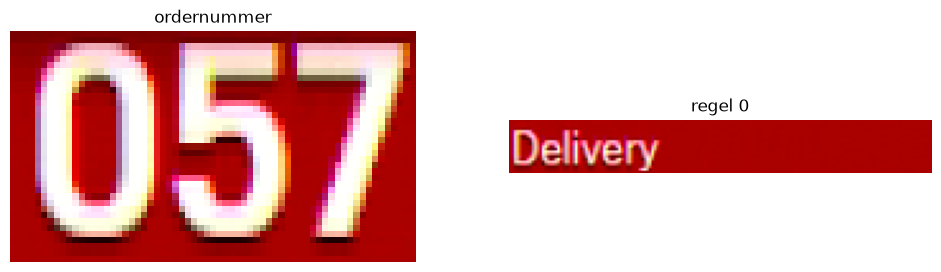

In [10]:
SEG, ROW = 0, 0

s = segs[SEG]
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
if s.number:
    ax[0].imshow(cv2.cvtColor(s.number.crop(fr.bgr), cv2.COLOR_BGR2RGB))
    ax[0].set_title("ordernummer")
if s.rows:
    ax[1].imshow(cv2.cvtColor(s.rows[ROW].crop(fr.bgr), cv2.COLOR_BGR2RGB))
    ax[1].set_title(f"regel {ROW}")
for a in ax:
    a.axis("off")
plt.show()


## Stap 5 — het eindresultaat uit `sim.json` (optioneel)

`sim.json` bevat wat de **volledige pijplijn** uiteindelijk van elk frame maakte (na correcties,
latching en adres-matching). Die file wordt pas aangemaakt als je de sim hebt gedraaid:

```bash
docker compose up sim      # schrijft sim/out/sim.json
```

Staat de file er nog niet, dan slaat de cel hieronder netjes over met een uitleg.

In [11]:
if not SIM_JSON.exists():
    print(f"sim.json nog niet aanwezig op {SIM_JSON}")
    print("Draai eerst de sim (bv. `docker compose up sim`) en voer deze cel opnieuw uit.")
else:
    sim = json.loads(SIM_JSON.read_text())
    bundle = sim.get(FRAME, {})
    if not bundle:
        print(f"Geen entry voor {FRAME} in sim.json.")
    for nr, e in bundle.items():
        print(f"#{nr}  timed={e['timed']}  values={e['values']}")
        print(f"     latches={e['latches']}")
        print(f"     conf={e['confidences']}  addr_latched={e['addr_latched']}")
        if e.get("address"):
            a = e["address"]
            print(f"     -> {a.get('straat')} {a.get('huisnummer')} {a.get('postcode')}"
                  f"  [{a.get('resolve')} {a.get('confidence')}]")
        print(f"     ocr={e['ocr']}")


#57  timed=False  values={'type': None, 'straat': None, 'postcode': None, 'huisnummer': None}
     latches={'type': False, 'straat': False, 'postcode': False, 'huisnummer': False}
     conf={'type': 0.0, 'straat': 0.0, 'postcode': 0.0, 'huisnummer': 0.0}  addr_latched=False
     ocr={'raw': {'type': 'Delivery', 'addr': 'P =2 / (9731 PB)137 VAN EYCKSTRAAT / O /', 'addr_digits': 'P 2 ( (9731 PB)137 VAN EYCKSTRAAT OI'}, 'norm': {'type': 'delivery', 'straat': 'p pb van eyckstraat o', 'postcode': '9731PB', 'huisnummer': 137}}
#66  timed=False  values={'type': None, 'straat': None, 'postcode': None, 'huisnummer': None}
     latches={'type': False, 'straat': False, 'postcode': False, 'huisnummer': False}
     conf={'type': 0.0, 'straat': 0.0, 'postcode': 0.0, 'huisnummer': 0.0}  addr_latched=False
     ocr={'raw': {'type': 'Carryout', 'addr': 'P =4 / O', 'addr_digits': None}, 'norm': {'type': 'carryout', 'straat': 'p o', 'postcode': None, 'huisnummer': None}}
#68  timed=False  values={'type':